# Iterative sample-based

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from alg3 import EpsilonEstimate
from alg2 import mse, ModelOptReg
import covariance_matrices
from alg1 import GenXData, GenYData

In [8]:
rng = np.random.default_rng(seed=77)

EPSILON = 0.1
N_TRIAL = 1000 # number of observations N
ASPECT_RATIO = 0.3 # aspect ratio (d/N)
D_TRIAL = int(ASPECT_RATIO * N_TRIAL) # number of parameters D

theta = rng.standard_normal(size=D_TRIAL)[:, np.newaxis]
theta = theta / np.linalg.norm(theta)

Sigma_bulk = covariance_matrices.bulk(D_TRIAL) # bulk covariance
Sigma_spiked = covariance_matrices.spiked(D_TRIAL) # spiked covariance

LAMBDA_0 = 1
DELTA = 10 ** -4
P = 1 / 4

In [ ]:
def IterativeSampleOptReg(Sigma, lambda_0, p, delta, theta_true, epsilon_true,
                           max_iter=100):
    """
    Runs the iterative sample-based optimal ridge regularization procedure
    for max_iter outer iterations (no early stopping), tracking lambda, mse, 
    and epsilon_hat at every step so convergence behavior can be inspected.

    If theta_true and epsilon_true are provided, also computes the oracle 
    lambda/mse (using ModelOptReg fed the true theta and epsilon) internally, 
    reusing the same S, V computed from X.

    Args:
        Sigma: the covariance matrix.
        lambda_0: the initial ridge regression parameter, often set to 1.
        p: the exponent parameter for the regularized rank, used in EpsilonEstimate.
        delta: the convergence tolerance on lambda, used for the inner (ModelOptReg) loop.
        theta_true: the true parameter vector, used to compute the oracle.
        epsilon_true: the true noise amplitude, used to compute the oracle.
        max_iter: number of outer iterations to run.

    Returns:
        (lambda_star, mse_star): lambda and mse from the final iteration.
        (lambdas, mses, noises): lists tracking lambda, mse, and epsilon_hat 
            across every outer iteration, in order.
        (lambda_oracle, mse_oracle): the oracle lambda/mse if theta_true and 
            epsilon_true were provided, else (None, None).
    """
    X = GenXData(N_TRIAL, D_TRIAL, Sigma)
    y = GenYData(X, N_TRIAL, theta, epsilon_true)

    U, sigma, Vt = np.linalg.svd(X, full_matrices=True)
    N, D = X.shape
    V = Vt.T
    min_D_N = min(N, D)

    S = np.zeros((N, D))
    S[:min_D_N, :min_D_N] = np.diag(sigma[:min_D_N])

    lam = lambda_0
    lam_prev = lambda_0 + 2 * delta
    theta_hat = V[:, :min_D_N] @ ((sigma[:min_D_N] / (sigma[:min_D_N]**2 + lambda_0))[:, np.newaxis] * (U[:, :min_D_N].T @ y))
    epsilon_hat = EpsilonEstimate(X, U, S, V, y, p, lambda_0)

    lambdas, mses, noises = [], [], []

    lambda_oracle, mse_oracle = ModelOptReg(S, V, theta_true, epsilon_true, lambda_0, delta)

    pbar = tqdm(range(max_iter), desc="IterativeSampleOptReg")
    for _ in pbar:
        # if abs(lam - lam_prev) <= delta:
        #     break
        # lam_prev = lam

        lam, _ = ModelOptReg(S, V, theta_hat, epsilon_hat, lam, delta)
        mse_curr = mse(S, V, theta_true, lam, epsilon_true)   # TRUE MSE (real theta/epsilon)

        theta_hat = V[:, :min_D_N] @ ((sigma[:min_D_N] / (sigma[:min_D_N]**2 + lam))[:, np.newaxis] * (U[:, :min_D_N].T @ y))
        epsilon_hat = EpsilonEstimate(X, U, S, V, y, p, lam)

        lambdas.append(lam)
        mses.append(mse_curr)
        noises.append(epsilon_hat)

        pbar.set_postfix(lam=f"{lam:.6g}", mse=f"{mse_curr:.6g}", eps=f"{epsilon_hat:.6g}")
    pbar.close()

    return (lam, mses[-1]), (lambdas, mses, noises), (lambda_oracle, mse_oracle)

In [10]:
(lam_star, mse_star), (lambdas, mses, noises), (lam_oracle, mse_oracle) = IterativeSampleOptReg(
    Sigma_spiked, LAMBDA_0, P, DELTA, theta_true=theta, epsilon_true=EPSILON, max_iter=10
)

IterativeSampleOptReg: 100%|██████████| 10/10 [00:00<00:00, 204.68it/s, eps=0.100074, lam=3.67666, mse=0.0128824]


In [11]:
print(f"Oracle:       lambda={lam_oracle:.6g}, mse={mse_oracle:.6g}")
print(f"Sample-based: lambda={lam_star:.6g}, mse={mse_star:.6g}  (after {len(mses)} iters)")

Oracle:       lambda=2.85823, mse=0.0128754
Sample-based: lambda=3.67666, mse=0.0128824  (after 10 iters)


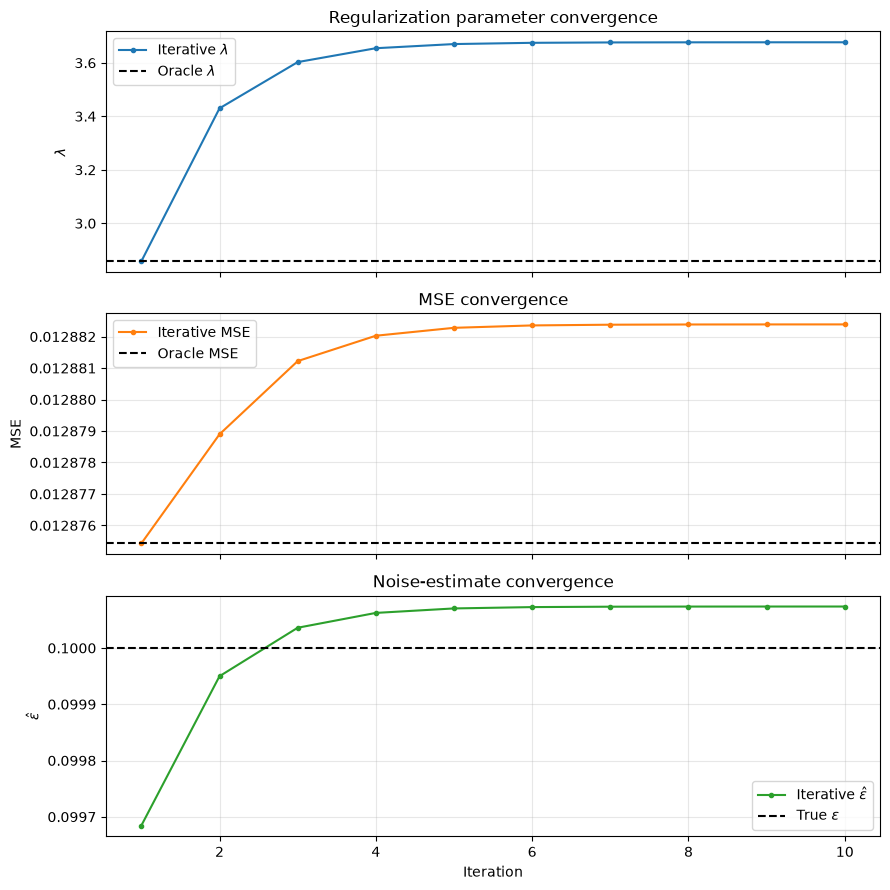

In [ ]:
iterations = np.arange(1, len(lambdas) + 1)
marker_size = 3

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

# Lambda
axes[0].plot(
    iterations, lambdas,
    marker="o", ms=marker_size,
    color="tab:blue",
    label=r"Iterative $\lambda$"
)
axes[0].axhline(
    lam_oracle,
    color="black", linestyle="--", linewidth=1.5,
    label=r"Oracle $\lambda$"
)
axes[0].set_ylabel(r"$\lambda$")
axes[0].set_title(r"Regularization parameter convergence")
axes[0].grid(alpha=0.3)
axes[0].legend()

# MSE
axes[1].plot(
    iterations, mses,
    marker="o", ms=marker_size,
    color="tab:orange",
    label="Iterative MSE"
)
axes[1].axhline(
    mse_oracle,
    color="black", linestyle="--", linewidth=1.5,
    label="Oracle MSE"
)
axes[1].set_ylabel("MSE")
axes[1].set_title("MSE convergence")
axes[1].grid(alpha=0.3)
axes[1].legend()

# Noise
axes[2].plot(
    iterations, noises,
    marker="o", ms=marker_size,
    color="tab:green",
    label=r"Iterative $\hat{\epsilon}$"
)
axes[2].axhline(
    EPSILON,
    color="black", linestyle="--", linewidth=1.5,
    label=r"True $\epsilon$"
)
axes[2].set_ylabel(r"$\hat{\epsilon}$")
axes[2].set_xlabel("Iteration")
axes[2].set_title(r"Noise-estimate convergence")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

IterativeSampleOptReg: 100%|██████████| 100/100 [00:00<00:00, 311.82it/s, eps=0.101178, lam=1.03339, mse=0.010989]


aspect_ratio=0.1 (D=100): lam=1.033 (oracle 0.8459), mse=0.01099 (oracle 0.01099), eps_hat=0.1012 (true 0.1)


IterativeSampleOptReg: 100%|██████████| 100/100 [00:00<00:00, 292.32it/s, eps=0.101183, lam=2.33567, mse=0.0119479]


aspect_ratio=0.2 (D=200): lam=2.336 (oracle 1.946), mse=0.01195 (oracle 0.01195), eps_hat=0.1012 (true 0.1)


IterativeSampleOptReg: 100%|██████████| 100/100 [00:00<00:00, 236.03it/s, eps=0.100074, lam=3.67668, mse=0.0128824]


...

aspect_ratio=0.5 (D=500): lam=8.129 (oracle 4.717), mse=0.0147 (oracle 0.01461), eps_hat=0.107 (true 0.1)


IterativeSampleOptReg: 100%|██████████| 100/100 [00:01<00:00, 77.24it/s, eps=0.112065, lam=11.6822, mse=0.0155558]


aspect_ratio=0.6 (D=600): lam=11.68 (oracle 6.02), mse=0.01556 (oracle 0.01536), eps_hat=0.1121 (true 0.1)


IterativeSampleOptReg: 100%|██████████| 100/100 [00:02<00:00, 39.49it/s, eps=0.132506, lam=20.3689, mse=0.0167987]


aspect_ratio=0.7 (D=700): lam=20.37 (oracle 7.001), mse=0.0168 (oracle 0.01608), eps_hat=0.1325 (true 0.1)


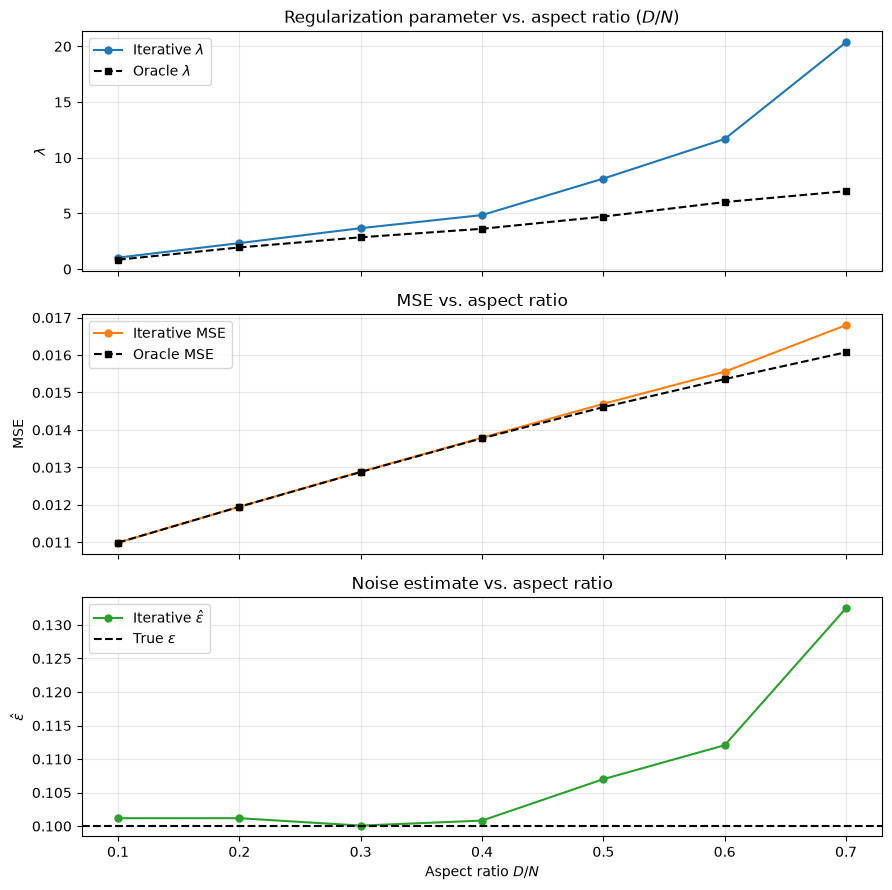

In [7]:
N_TRIAL = 1000
EPSILON = 0.1
LAMBDA_0 = 1
DELTA = 10 ** -4
P = 1 / 4

aspect_ratios = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]) # cut 0.8, 0.9 for ease of seeing other results

lam_stars, mse_stars, eps_finals = [], [], []
lam_oracles, mse_oracles = [], []

for ar in aspect_ratios:
    D_TRIAL = int(ar * N_TRIAL)

    rng = np.random.default_rng(seed=77)
    theta = rng.standard_normal(size=D_TRIAL)[:, np.newaxis]
    theta = theta / np.linalg.norm(theta)

    Sigma_spiked = covariance_matrices.spiked(D_TRIAL)

    (lam_star, mse_star), (lambdas, mses, noises), (lam_oracle, mse_oracle) = IterativeSampleOptReg(
        Sigma_spiked, LAMBDA_0, P, DELTA, theta_true=theta, epsilon_true=EPSILON, max_iter=100
    )

    lam_stars.append(lam_star)
    mse_stars.append(mse_star)
    eps_finals.append(noises[-1])
    lam_oracles.append(lam_oracle)
    mse_oracles.append(mse_oracle)

    print(f"aspect_ratio={ar:.1f} (D={D_TRIAL}): "
          f"lam={lam_star:.4g} (oracle {lam_oracle:.4g}), "
          f"mse={mse_star:.4g} (oracle {mse_oracle:.4g}), "
          f"eps_hat={noises[-1]:.4g} (true {EPSILON})")

lam_stars, mse_stars, eps_finals = map(np.array, (lam_stars, mse_stars, eps_finals))
lam_oracles, mse_oracles = map(np.array, (lam_oracles, mse_oracles))

marker_size = 5

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(aspect_ratios, lam_stars, marker="o", ms=marker_size, color="tab:blue", label=r"Iterative $\lambda$")
axes[0].plot(aspect_ratios, lam_oracles, marker="s", ms=marker_size, color="black", linestyle="--", label=r"Oracle $\lambda$")
axes[0].set_ylabel(r"$\lambda$")
axes[0].set_title(r"Regularization parameter vs. aspect ratio ($D/N$)")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(aspect_ratios, mse_stars, marker="o", ms=marker_size, color="tab:orange", label="Iterative MSE")
axes[1].plot(aspect_ratios, mse_oracles, marker="s", ms=marker_size, color="black", linestyle="--", label="Oracle MSE")
axes[1].set_ylabel("MSE")
axes[1].set_title("MSE vs. aspect ratio")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(aspect_ratios, eps_finals, marker="o", ms=marker_size, color="tab:green", label=r"Iterative $\hat{\epsilon}$")
axes[2].axhline(EPSILON, color="black", linestyle="--", linewidth=1.5, label=r"True $\epsilon$")
axes[2].set_ylabel(r"$\hat{\epsilon}$")
axes[2].set_xlabel(r"Aspect ratio $D/N$")
axes[2].set_title("Noise estimate vs. aspect ratio")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()